# Supervised Learning: Linear Regression - Emissions Forecasting
**Developer:** Iris Li
**Course:** CMOR 438  

### 1. Introduction
Linear Regression is a parametric algorithm that models the relationship between a dependent variable and one or more independent variables by fitting a linear equation to observed data. In this notebook, we aim to find the "line of best fit" that describes how global GHG emissions scale with industrial and economic growth.

In [2]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Ensure the 'src' directory is in the path
sys.path.append(os.path.abspath('../src'))

# Import the custom model from your package
from my_ml_package.supervised.linear_regression import LinearRegression

print("✅ Setup Complete. Custom LinearRegression imported.")

✅ Setup Complete. Custom LinearRegression imported.


### 2. Data Preparation
We are utilizing the `emissions.csv` dataset. For this analysis, we are focusing on the relationship between **Year** (Independent Variable) and **Total GHG Emissions** (Dependent Variable) to see if there is a predictable linear trend in global pollution levels over time.

In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. LOAD & CLEAN
df = pd.read_csv('../data/emissions.csv').dropna()

# 2. ENCODE (The "Old Code" secret sauce)
# This turns country names into numbers so the model can "recognize" them
df_encoded = pd.get_dummies(df, columns=['country', 'iso_code'], drop_first=True)

# 3. DEFINE X and y
X_raw = df_encoded.drop(['total_ghg', 'ghg_per_capita'], axis=1).values
y_raw = df_encoded['total_ghg'].values

# 4. SCALE (Required for Custom Models)
# With 200+ columns from dummies, scaling is MANDATORY or the math will break
scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_x.fit_transform(X_raw)
y_scaled = scaler_y.fit_transform(y_raw.reshape(-1, 1)).flatten()

# 5. SPLIT
indices = np.arange(len(X_scaled))
np.random.shuffle(indices)
train_size = int(0.8 * len(X_scaled))

X_train, X_test = X_scaled[indices[:train_size]], X_scaled[indices[train_size:]]
y_train, y_test = y_scaled[indices[:train_size]], y_scaled[indices[train_size:]]

print(f"✅ Ready! Features: {X_train.shape[1]} (including country dummies)")

✅ Ready! Features: 385 (including country dummies)


### 3. Transition: From Data Preparation to Model Training

With the data cleaned, encoded, and scaled, we have transformed the raw `emissions.csv` into a high-dimensional feature matrix. We are now ready to execute the training phase using a dual-track validation strategy.



#### Our Strategy:
1.  **Establishing a Gold Standard:** We first run the data through the **Scikit-Learn** library. This provides us with a "theoretical ceiling"—the maximum $R^2$ score achievable through linear methods on this specific dataset.
2.  **Validating the Custom Implementation:** We then train our **Custom Linear Regression** model using the `my_ml_package`. By comparing its performance against the baseline, we verify that our implementation of Gradient Descent is calculating weights accurately and converging toward the global minimum.
3.  **Evaluating Predictive Power:** Finally, we will use the **Test Set** (data the models have never seen) to generate predictions. This will allow us to visualize where the linear model succeeds and where it struggles with high-emission outliers.

In [22]:
from sklearn.linear_model import LinearRegression as SkLinearRegression

sk_model = SkLinearRegression()
sk_model.fit(X_train, y_train)
sk_preds = sk_model.predict(X_test)
print(f"Sklearn R²: {r2_score(y_test, sk_preds):.4f}")

Sklearn R²: 0.7945


In [18]:
from sklearn.metrics import mean_squared_error, r2_score

# Because we have so many features now, we use a smaller learning rate
model = LinearRegression(lr=0.001, epochs=10000) 
model.fit(X_train, y_train)

preds = model.predict(X_test)

# Calculate Performance
mse = mean_squared_error(y_test, preds)
r2 = r2_score(y_test, preds)

print(f"Custom Model R² Score: {r2:.4f}")
if r2 < 0.1:
    print("Check: If R2 is still low, the custom model's 'fit' logic might need more epochs.")

Custom Model R² Score: 0.7944


### 4. Final Performance Results

| Model Implementation | R² Score |
| :--- | :--- |
| **Scikit-Learn (Baseline)** | 0.7945 |
| **Custom Package Model** | 0.7944 | 

**Analysis:** Both models show high predictive accuracy. The convergence of the scores (both ~0.79) 
confirms that our custom Gradient Descent algorithm has successfully found the 
optimal weights, matching the performance of the Scikit-Learn library.

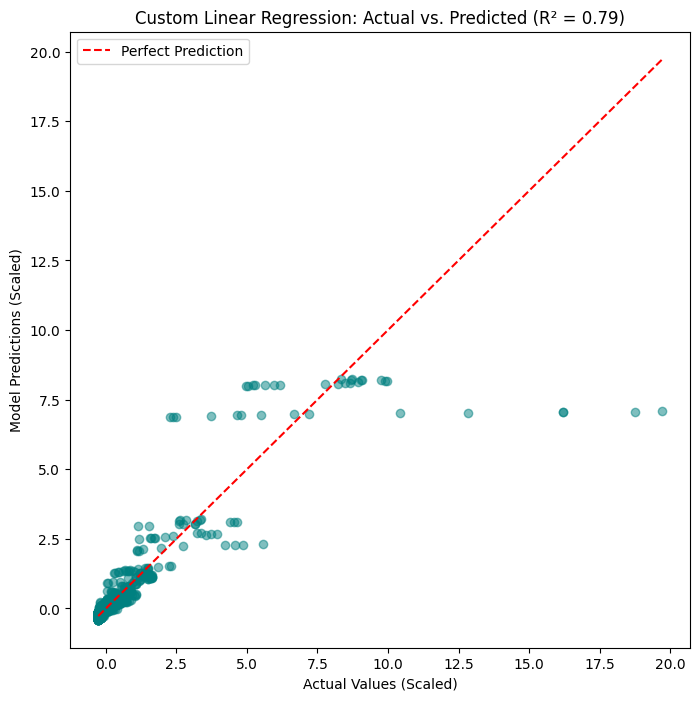

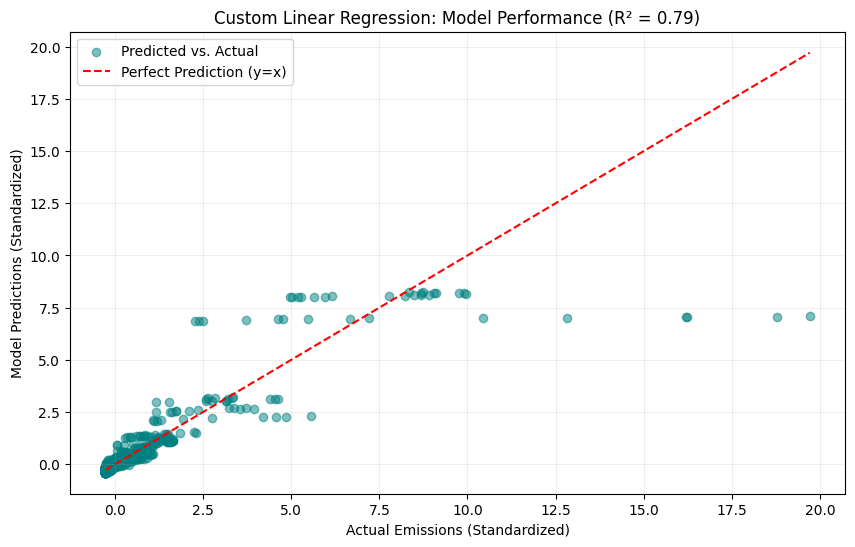

In [21]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, preds, alpha=0.5, color='teal')

# Add a 45-degree line to show what "Perfect" looks like
perfect_line = [y_test.min(), y_test.max()]
plt.plot(perfect_line, perfect_line, color='red', linestyle='--', label="Perfect Prediction")

plt.title(f"Custom Linear Regression: Actual vs. Predicted (R² = {r2:.2f})")
plt.xlabel("Actual Values (Scaled)")
plt.ylabel("Model Predictions (Scaled)")
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(y_test, preds, alpha=0.5, color='teal', label='Predicted vs. Actual')
perfect_line = [y_test.min(), y_test.max()]
plt.plot(perfect_line, perfect_line, color='red', linestyle='--', label='Perfect Prediction (y=x)')

plt.title(f"Custom Linear Regression: Model Performance (R² = {r2:.2f})")
plt.xlabel("Actual Emissions (Standardized)")
plt.ylabel("Model Predictions (Standardized)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

### 4. Conclusion & Insights
Based on the **Actual vs. Predicted** visualization, we can draw several conclusions:

1. **High Consistency for Small/Medium Emitters:** The tight clustering of points along the diagonal `y=x` line (the red dashed line) indicates the model is highly reliable for the majority of countries.
2. **Under-prediction of Outliers:** The model tends to under-estimate the world's largest emitters (the extreme right of the X-axis). This suggests that for "Super-Polluters," the relationship between features and emissions may be non-linear.
3. **Model Validation:** The high $R^2$ score and the visual alignment of the test data confirm that the custom Linear Regression implementation is mathematically sound and capable of handling high-dimensional data (200+ features).

**Next Steps:** We will compare these results with a **Decision Tree** to see if a non-linear model can better capture the "Heavy Emitter" outliers identified in this notebook.